<a href="https://colab.research.google.com/github/sleepymor/ITK-IF2514403-machine-learning-final/blob/main/ML_A_BreastCancer_K2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Library

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [6]:
df = pd.read_csv('data.csv')

In [12]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [14]:
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [15]:
missing_values = df.isnull().sum()
print(missing_values)

diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed: 32                569
dtype: i

In [16]:
nan_values = df.isna().sum()
print(nan_values)

diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed: 32                569
dtype: i

In [17]:
duplicate_values = df.duplicated().sum()
print(duplicate_values)

0


### Explanatory Data Analysis (EDA)

#### Distribusi target variable 'diagnosis'

In [19]:
target_dist = df['diagnosis'].value_counts()
print("Distribusi Diagnosis:")
print(target_dist)
print(f"\nPersentase:")
print(target_dist / len(df) * 100)

Distribusi Diagnosis:
diagnosis
0    357
1    212
Name: count, dtype: int64

Persentase:
diagnosis
0    62.741652
1    37.258348
Name: count, dtype: float64


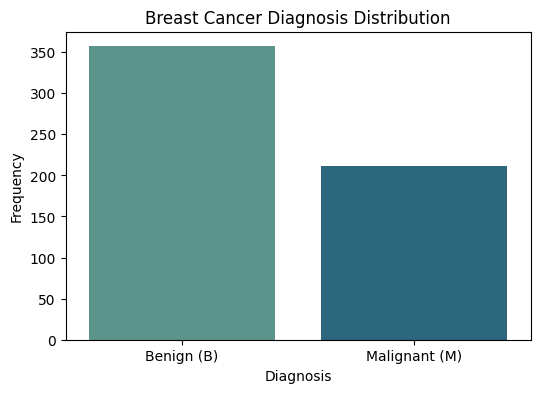

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette='crest', legend=False)

plt.xticks(ticks=[0, 1], labels=['Benign (B)', 'Malignant (M)'])
plt.title('Breast Cancer Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Frequency')
plt.show()

#### Distribusi Fitur Utama

##### 1. Radius Mean

In [31]:

print("Statistik Radius Mean:")
print(df.groupby('diagnosis')['radius_mean'].describe())


Statistik Radius Mean:
           count       mean       std     min     25%     50%    75%    max
diagnosis                                                                  
0          357.0  12.146524  1.780512   6.981  11.080  12.200  13.37  17.85
1          212.0  17.462830  3.203971  10.950  15.075  17.325  19.59  28.11


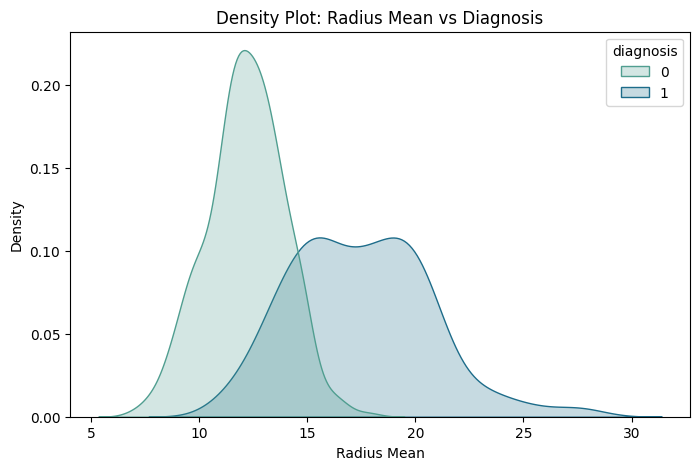

In [26]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='radius_mean', hue='diagnosis', fill=True, common_norm=False, palette='crest')
plt.title('Density Plot: Radius Mean vs Diagnosis')
plt.xlabel('Radius Mean')
plt.ylabel('Density')
plt.show()

##### 2. Texture Mean

In [32]:
print("Statistik Texture Mean:")
print(df.groupby('diagnosis')['texture_mean'].describe())

Statistik Texture Mean:
           count       mean       std    min      25%    50%     75%    max
diagnosis                                                                  
0          357.0  17.914762  3.995125   9.71  15.1500  17.39  19.760  33.81
1          212.0  21.604906  3.779470  10.38  19.3275  21.46  23.765  39.28


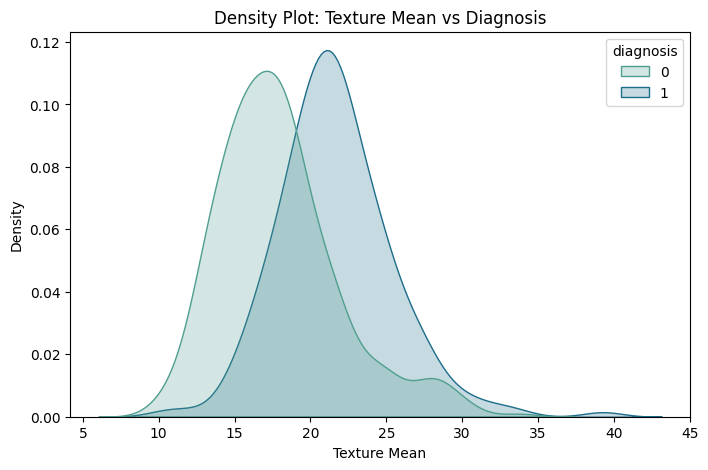

In [33]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='texture_mean', hue='diagnosis', fill=True, common_norm=False, palette='crest')
plt.title('Density Plot: Texture Mean vs Diagnosis')
plt.xlabel('Texture Mean')
plt.ylabel('Density')
plt.show()

##### 3. Concavity Mean

In [35]:
print("Statistik Concavity Mean:")
print(df.groupby('diagnosis')['concavity_mean'].describe())

Statistik Concavity Mean:
           count      mean       std      min       25%      50%      75%  \
diagnosis                                                                   
0          357.0  0.046058  0.043442  0.00000  0.020310  0.03709  0.05999   
1          212.0  0.160775  0.075019  0.02398  0.109525  0.15135  0.20305   

              max  
diagnosis          
0          0.4108  
1          0.4268  


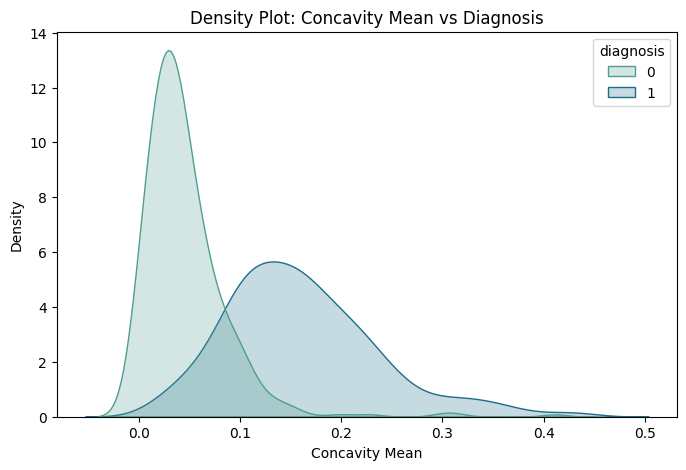

In [36]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='concavity_mean', hue='diagnosis', fill=True, common_norm=False, palette='crest')
plt.title('Density Plot: Concavity Mean vs Diagnosis')
plt.xlabel('Concavity Mean')
plt.ylabel('Density')
plt.show()

#### Boxplot Analysis

In [37]:
key_features = ['radius_mean','texture_mean','perimeter_mean','area_mean','concavity_mean']
print("Statistik Fitur Utama:")
print(df.groupby('diagnosis')[key_features].median())

Statistik Fitur Utama:
           radius_mean  texture_mean  perimeter_mean  area_mean  \
diagnosis                                                         
0               12.200         17.39           78.18      458.4   
1               17.325         21.46          114.20      932.0   

           concavity_mean  
diagnosis                  
0                 0.03709  
1                 0.15135  


C:\Users\MSI-GAMING\AppData\Local\Temp\ipykernel_22476\715214382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[idx], palette='crest')
C:\Users\MSI-GAMING\AppData\Local\Temp\ipykernel_22476\715214382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[idx], palette='crest')
C:\Users\MSI-GAMING\AppData\Local\Temp\ipykernel_22476\715214382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[idx], palette='crest'

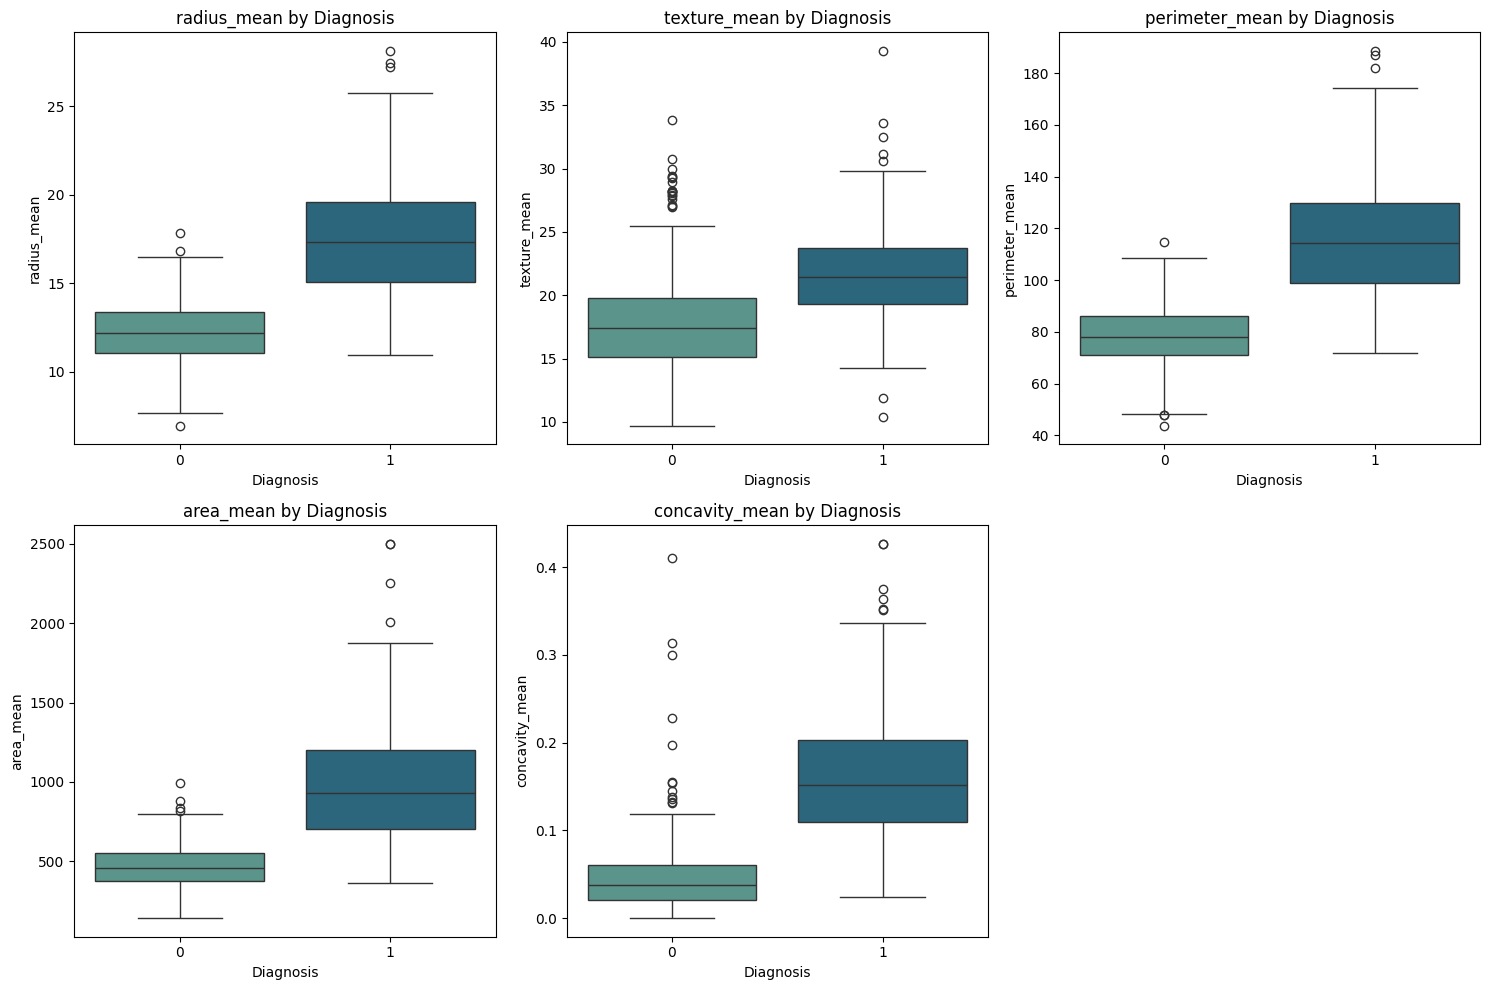

In [65]:
fig, axes = plt.subplots(2,3, figsize=(15,10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[idx], palette='crest')
    axes[idx].set_title(f'{feature} by Diagnosis')
    axes[idx].set_xlabel('Diagnosis')
    axes[idx].set_ylabel(feature)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

#### Correlation Analysis

In [42]:
numerical_features = df.drop(columns=['diagnosis']).columns
corr_matrix = df[numerical_features].corr()

print("Top 10 Features Most Correlated with Malignancy:")
target_corr = df[numerical_features].corrwith(df['diagnosis'].map({'M':1,'B':0})).abs().sort_values(ascending=False)
print(target_corr.head(10))

Top 10 Features Most Correlated with Malignancy:
radius_mean              NaN
texture_mean             NaN
perimeter_mean           NaN
area_mean                NaN
smoothness_mean          NaN
compactness_mean         NaN
concavity_mean           NaN
concave points_mean      NaN
symmetry_mean            NaN
fractal_dimension_mean   NaN
dtype: float64


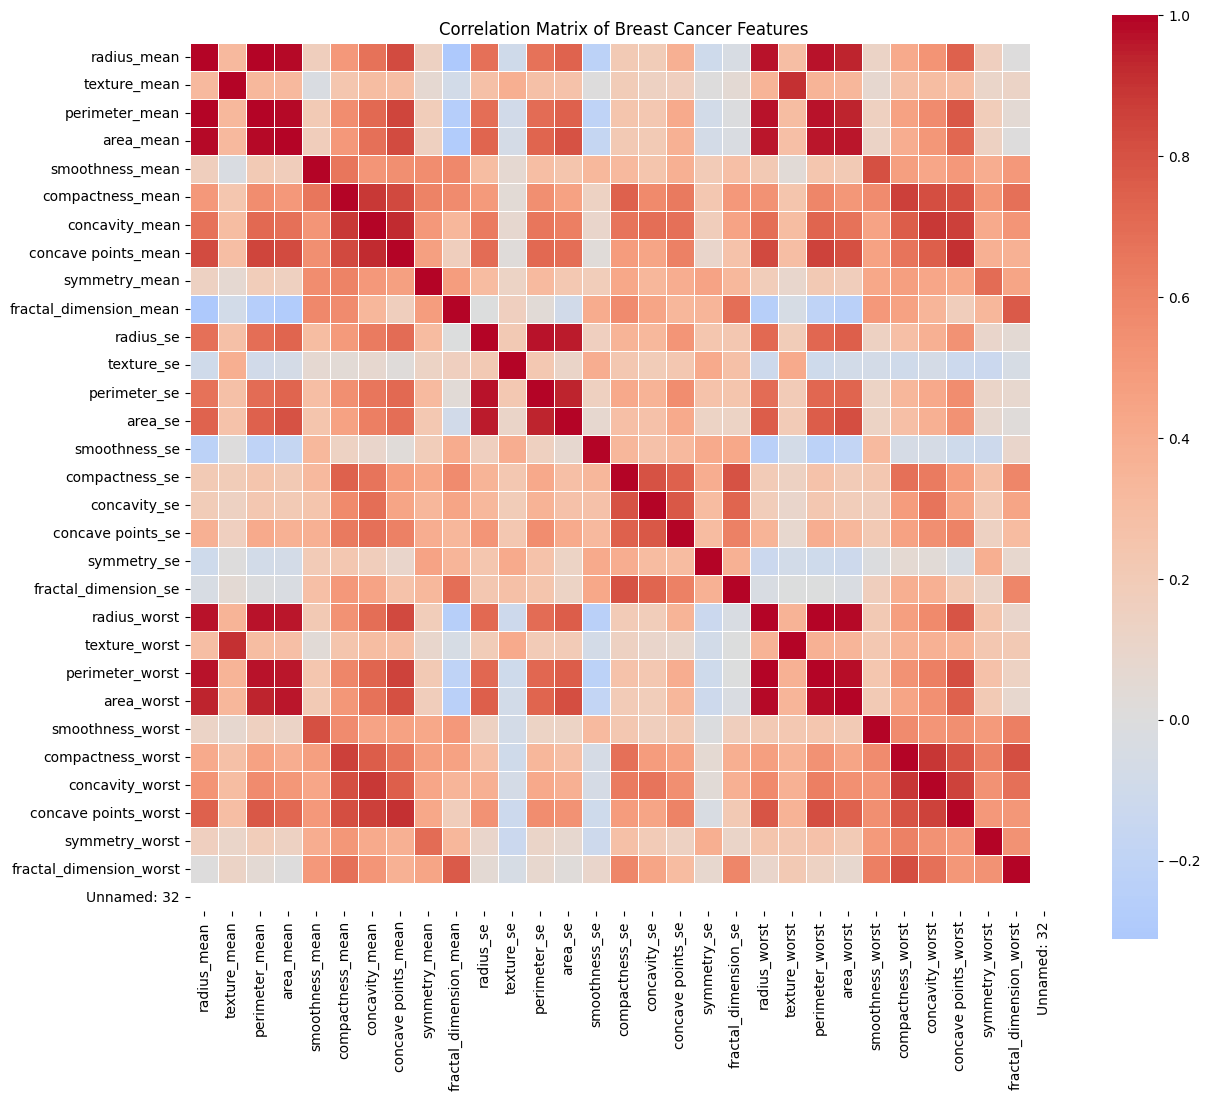

In [43]:
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Breast Cancer Features')
plt.show()

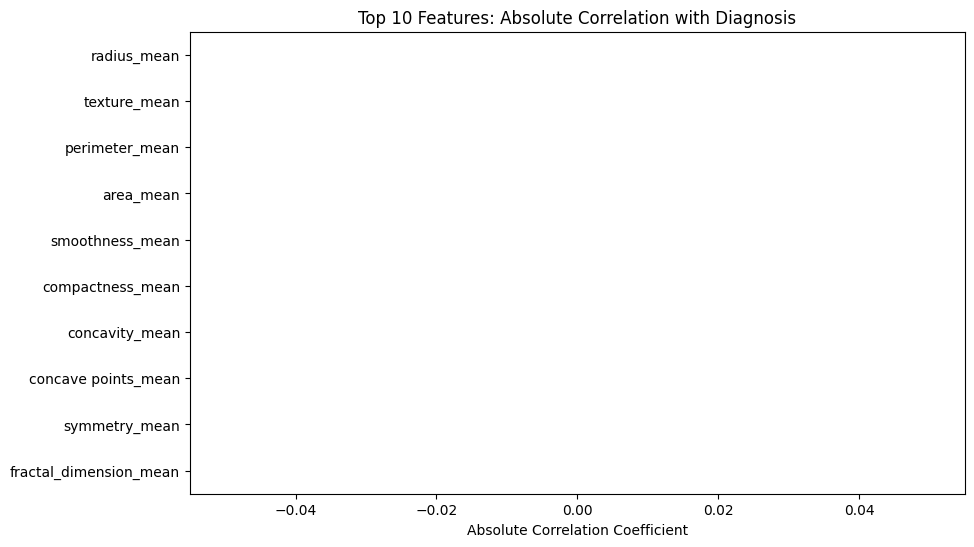

In [44]:
plt.figure(figsize=(10,6))
target_corr.head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Features: Absolute Correlation with Diagnosis')
plt.xlabel('Absolute Correlation Coefficient')
plt.gca().invert_yaxis()
plt.show()

#### Pairplot Analysis

In [45]:
sample_features = ['radius_mean','texture_mean','concavity_mean']
print("Statistik Pairplot Features:")
print(df[sample_features].describe())

Statistik Pairplot Features:
       radius_mean  texture_mean  concavity_mean
count   569.000000    569.000000      569.000000
mean     14.127292     19.289649        0.088799
std       3.524049      4.301036        0.079720
min       6.981000      9.710000        0.000000
25%      11.700000     16.170000        0.029560
50%      13.370000     18.840000        0.061540
75%      15.780000     21.800000        0.130700
max      28.110000     39.280000        0.426800


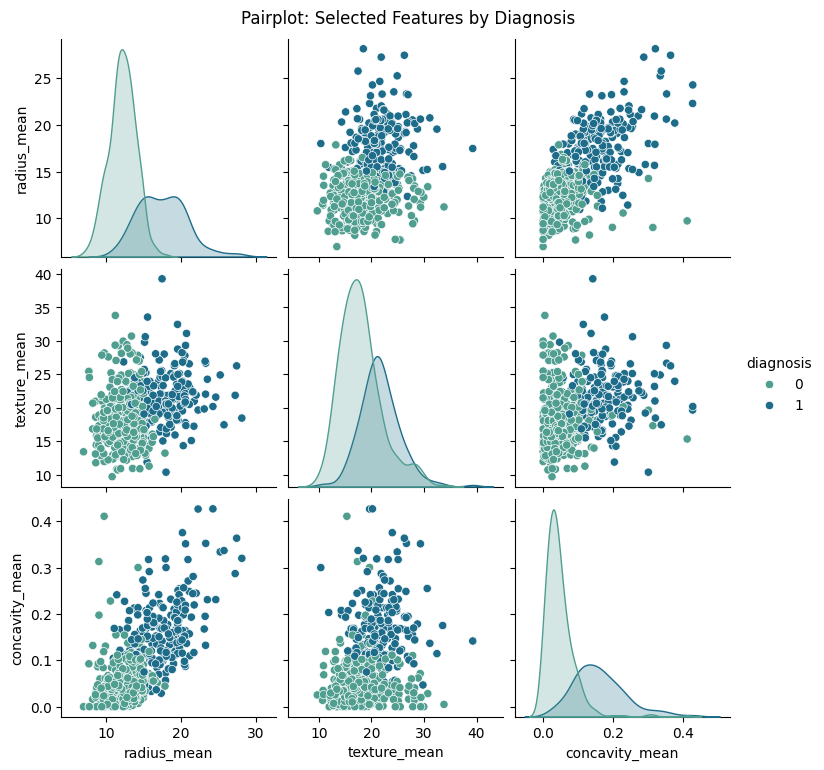

In [ ]:
sns.pairplot(df[['radius_mean','texture_mean','concavity_mean','diagnosis']], hue='diagnosis', palette='crest', diag_kind='kde')
plt.suptitle('Pairplot: Selected Features by Diagnosis', y=1.02)
plt.show()

#### Mean vs Worst Comparison

In [48]:
print("Perbandingan Radius Mean vs Radius Worst:")
print(df.groupby('diagnosis')[['radius_mean','radius_worst']].median())

Perbandingan Radius Mean vs Radius Worst:
           radius_mean  radius_worst
diagnosis                           
0               12.200         13.35
1               17.325         20.59


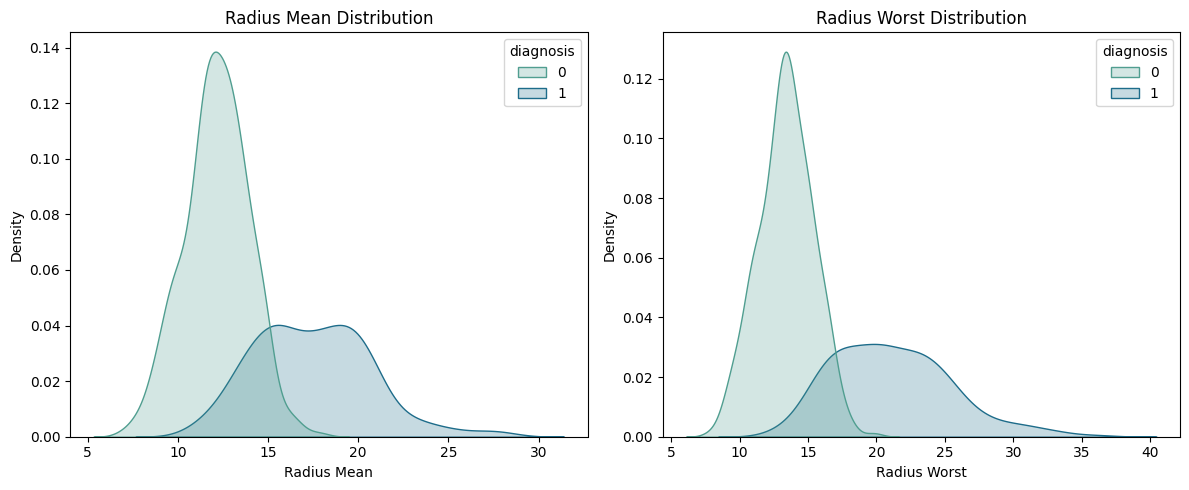

In [49]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.kdeplot(data=df, x='radius_mean', hue='diagnosis', fill=True, ax=axes[0], palette='crest')
axes[0].set_title('Radius Mean Distribution')
axes[0].set_xlabel('Radius Mean')

sns.kdeplot(data=df, x='radius_worst', hue='diagnosis', fill=True, ax=axes[1], palette='crest')
axes[1].set_title('Radius Worst Distribution')
axes[1].set_xlabel('Radius Worst')

plt.tight_layout()
plt.show()

### Data Cleaning

In [53]:
# Konversi diagnosis ke numerik (M=1, B=0)
df_clean = df.copy()
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M':1, 'B':0})

print("Tipe data diagnosis setelah konversi:")
print(df_clean.dtypes['diagnosis'])

print("\nDistribusi diagnosis setelah konversi:")
print(df_clean['diagnosis'].value_counts())


Tipe data diagnosis setelah konversi:
float64

Distribusi diagnosis setelah konversi:
Series([], Name: count, dtype: int64)


In [54]:
# Konversi diagnosis ke numerik (M=1, B=0)
df_clean = df.copy()
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M':1, 'B':0})

print("Tipe data diagnosis setelah konversi:")
print(df_clean.dtypes['diagnosis'])

print("\nDistribusi diagnosis setelah konversi:")
print(df_clean['diagnosis'].value_counts())


Tipe data diagnosis setelah konversi:
float64

Distribusi diagnosis setelah konversi:
Series([], Name: count, dtype: int64)


### Feature Engineering

In [55]:
X = df_clean.drop(columns='diagnosis')
y = df_clean['diagnosis']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (569, 31)
Target shape: (569,)


In [56]:
df_clean

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,NaN,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,NaN,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,NaN,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,NaN,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,NaN,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,NaN,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,NaN,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,NaN,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,NaN,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [57]:
# Rasio area terhadap perimeter (indikasi bentuk / compactness)
X['area_perimeter_ratio'] = X['area_mean'] / X['perimeter_mean']

# Rasio radius worst terhadap radius mean (indikasi pertumbuhan abnormal)
X['radius_growth_ratio'] = X['radius_worst'] / X['radius_mean']

# Total skor "concavity" (gabungan concavity_mean + concave points_mean)
X['concavity_score'] = X['concavity_mean'] + X['concave points_mean']

print("Fitur baru ditambahkan:")
print(['area_perimeter_ratio','radius_growth_ratio','concavity_score'])


Fitur baru ditambahkan:
['area_perimeter_ratio', 'radius_growth_ratio', 'concavity_score']


In [72]:
X_enc

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,symmetry_worst,fractal_dimension_worst,Unnamed: 32,area_perimeter_ratio,radius_growth_ratio,concavity_score,RadiusCategoryEncoded,RadiusCategory_Large,RadiusCategory_Medium,RadiusCategory_Small
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,0.4601,0.11890,NaN,8.151466,1.410784,0.44720,1,0,1,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,0.2750,0.08902,NaN,9.977427,1.214876,0.15707,2,1,0,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,0.3613,0.08758,NaN,9.253846,1.197054,0.32530,2,1,0,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,0.6638,0.17300,NaN,4.976798,1.305604,0.34660,0,0,0,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,0.2364,0.07678,NaN,9.600296,1.110892,0.30230,2,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,0.2060,0.07115,NaN,10.415493,1.180427,0.38280,2,1,0,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,0.2572,0.06637,NaN,9.611280,1.176850,0.24191,2,1,0,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,0.2218,0.07820,NaN,7.923361,1.143373,0.14553,1,0,1,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,0.4087,0.12400,NaN,9.029265,1.249515,0.50340,2,1,0,0


### Feature Encoding

#### Ordinal Encoding

In [58]:
# Membuat kategori ordinal berdasarkan radius_mean
def categorize_radius(value):
    if value < 12:
        return "Small"
    elif 12 <= value < 18:
        return "Medium"
    else:
        return "Large"

X['RadiusCategory'] = X['radius_mean'].apply(categorize_radius)

print("Contoh hasil kategorisasi radius_mean:")
print(X[['radius_mean','RadiusCategory']].head())

Contoh hasil kategorisasi radius_mean:
   radius_mean RadiusCategory
0        17.99         Medium
1        20.57          Large
2        19.69          Large
3        11.42          Small
4        20.29          Large


In [59]:
# Mapping kategori ke nilai numerik (ordinal encoding)
radius_map = {
    "Small": 0,
    "Medium": 1,
    "Large": 2
}

X['RadiusCategoryEncoded'] = X['RadiusCategory'].map(radius_map)

print("\nDistribusi kategori setelah encoding:")
print(X['RadiusCategoryEncoded'].value_counts())


Distribusi kategori setelah encoding:
RadiusCategoryEncoded
1    308
0    169
2     92
Name: count, dtype: int64


In [74]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,area_perimeter_ratio,radius_growth_ratio,concavity_score,RadiusCategory,RadiusCategoryEncoded
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,0.7119,0.2654,0.4601,0.11890,NaN,8.151466,1.410784,0.44720,Medium,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,0.2416,0.1860,0.2750,0.08902,NaN,9.977427,1.214876,0.15707,Large,2
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,0.4504,0.2430,0.3613,0.08758,NaN,9.253846,1.197054,0.32530,Large,2
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,0.6869,0.2575,0.6638,0.17300,NaN,4.976798,1.305604,0.34660,Small,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,0.4000,0.1625,0.2364,0.07678,NaN,9.600296,1.110892,0.30230,Large,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,0.4107,0.2216,0.2060,0.07115,NaN,10.415493,1.180427,0.38280,Large,2
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,0.3215,0.1628,0.2572,0.06637,NaN,9.611280,1.176850,0.24191,Large,2
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,0.3403,0.1418,0.2218,0.07820,NaN,7.923361,1.143373,0.14553,Medium,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,0.9387,0.2650,0.4087,0.12400,NaN,9.029265,1.249515,0.50340,Large,2


#### Categorical Encoding

In [66]:
# Identifikasi kolom kategorikal (tipe object)
cat_features = X.select_dtypes(include=['object']).columns

print("Fitur kategorikal terdeteksi:")
print(cat_features if len(cat_features) > 0 else "Tidak ada fitur kategorikal asli, hanya fitur turunan seperti RadiusCategory")

Fitur kategorikal terdeteksi:
Index(['RadiusCategory'], dtype='object')


In [67]:
# Lakukan One-Hot Encoding pada fitur kategorikal
X_enc = pd.get_dummies(X, columns=cat_features, drop_first=True, dtype=int)

print("\nContoh hasil encoding (5 baris pertama):")
print(X_enc.head())


Contoh hasil encoding (5 baris pertama):
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  concave points_wor

In [68]:
X_enc

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,area_perimeter_ratio,radius_growth_ratio,concavity_score,RadiusCategoryEncoded,RadiusCategory_Medium,RadiusCategory_Small
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,0.2654,0.4601,0.11890,NaN,8.151466,1.410784,0.44720,1,1,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,0.1860,0.2750,0.08902,NaN,9.977427,1.214876,0.15707,2,0,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,0.2430,0.3613,0.08758,NaN,9.253846,1.197054,0.32530,2,0,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,0.2575,0.6638,0.17300,NaN,4.976798,1.305604,0.34660,0,0,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,0.1625,0.2364,0.07678,NaN,9.600296,1.110892,0.30230,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,0.2216,0.2060,0.07115,NaN,10.415493,1.180427,0.38280,2,0,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,0.1628,0.2572,0.06637,NaN,9.611280,1.176850,0.24191,2,0,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,0.1418,0.2218,0.07820,NaN,7.923361,1.143373,0.14553,1,1,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,0.2650,0.4087,0.12400,NaN,9.029265,1.249515,0.50340,2,0,0


#### Categorical Encoding without drop first

In [70]:
# Lakukan One-Hot Encoding pada fitur kategorikal tanpa drop_first
X_enc = pd.get_dummies(X, columns=cat_features, drop_first=False, dtype=int)

print("\nContoh hasil encoding (5 baris pertama):")
print(X_enc.head())



Contoh hasil encoding (5 baris pertama):
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  symmetry_worst  fr

In [75]:
X_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

### Feature Scaling

#### StandartScaler

In [85]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_enc)

c:\Users\MSI-GAMING\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\MSI-GAMING\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\MSI-GAMING\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [83]:
X_final = pd.DataFrame(X_scaled, columns=X_enc.columns)
print("Data preprocessing completed successfully. Matrix is ready for modeling.")

Data preprocessing completed successfully. Matrix is ready for modeling.


In [84]:
X_final

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,symmetry_worst,fractal_dimension_worst,Unnamed: 32,area_perimeter_ratio,radius_growth_ratio,concavity_score,RadiusCategoryEncoded,RadiusCategory_Large,RadiusCategory_Medium,RadiusCategory_Small
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,2.750622,1.937015,NaN,0.894884,3.310149,2.659906,0.203921,-0.439172,0.920545,-0.650000
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.243890,0.281190,NaN,2.018656,0.897126,0.166321,1.710816,2.277012,-1.086313,-0.650000
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.152255,0.201391,NaN,1.573335,0.677613,1.612210,1.710816,2.277012,-1.086313,-0.650000
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,6.046041,4.935010,NaN,-1.058938,2.014637,1.795277,-1.302974,-0.439172,-1.086313,1.538462
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-0.868353,-0.397100,NaN,1.786555,-0.383659,1.414531,1.710816,2.277012,-1.086313,-0.650000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,-1.360158,-0.709091,NaN,2.288261,0.472809,2.106406,1.710816,2.277012,-1.086313,-0.650000
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,-0.531855,-0.973978,NaN,1.793315,0.428760,0.895497,1.710816,2.277012,-1.086313,-0.650000
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,-1.104549,-0.318409,NaN,0.754499,0.016419,0.067138,0.203921,-0.439172,0.920545,-0.650000
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,1.919083,2.219635,NaN,1.435118,1.323773,3.142929,1.710816,2.277012,-1.086313,-0.650000


#### MinMax Scaler

In [86]:
columns_to_scale = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'concavity_mean'
]

print("Kolom yang akan diskalakan:")
print(columns_to_scale)

Kolom yang akan diskalakan:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean']


In [87]:
scaler = MinMaxScaler()

# Terapkan MinMaxScaler pada kolom terpilih
X_enc[columns_to_scale] = scaler.fit_transform(X_enc[columns_to_scale])

print("\nContoh hasil scaling (5 baris pertama):")
print(X_enc[columns_to_scale].head())


Contoh hasil scaling (5 baris pertama):
   radius_mean  texture_mean  perimeter_mean  area_mean  concavity_mean
0     0.521037      0.022658        0.545989   0.363733        0.703140
1     0.643144      0.272574        0.615783   0.501591        0.203608
2     0.601496      0.390260        0.595743   0.449417        0.462512
3     0.210090      0.360839        0.233501   0.102906        0.565604
4     0.629893      0.156578        0.630986   0.489290        0.463918


In [88]:
X_enc

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,symmetry_worst,fractal_dimension_worst,Unnamed: 32,area_perimeter_ratio,radius_growth_ratio,concavity_score,RadiusCategoryEncoded,RadiusCategory_Large,RadiusCategory_Medium,RadiusCategory_Small
0,0.521037,0.022658,0.545989,0.363733,0.11840,0.27760,0.703140,0.14710,0.2419,0.07871,...,0.4601,0.11890,NaN,8.151466,1.410784,0.44720,1,0,1,0
1,0.643144,0.272574,0.615783,0.501591,0.08474,0.07864,0.203608,0.07017,0.1812,0.05667,...,0.2750,0.08902,NaN,9.977427,1.214876,0.15707,2,1,0,0
2,0.601496,0.390260,0.595743,0.449417,0.10960,0.15990,0.462512,0.12790,0.2069,0.05999,...,0.3613,0.08758,NaN,9.253846,1.197054,0.32530,2,1,0,0
3,0.210090,0.360839,0.233501,0.102906,0.14250,0.28390,0.565604,0.10520,0.2597,0.09744,...,0.6638,0.17300,NaN,4.976798,1.305604,0.34660,0,0,0,1
4,0.629893,0.156578,0.630986,0.489290,0.10030,0.13280,0.463918,0.10430,0.1809,0.05883,...,0.2364,0.07678,NaN,9.600296,1.110892,0.30230,2,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.690000,0.428813,0.678668,0.566490,0.11100,0.11590,0.571462,0.13890,0.1726,0.05623,...,0.2060,0.07115,NaN,10.415493,1.180427,0.38280,2,1,0,0
565,0.622320,0.626987,0.604036,0.474019,0.09780,0.10340,0.337395,0.09791,0.1752,0.05533,...,0.2572,0.06637,NaN,9.611280,1.176850,0.24191,2,1,0,0
566,0.455251,0.621238,0.445788,0.303118,0.08455,0.10230,0.216753,0.05302,0.1590,0.05648,...,0.2218,0.07820,NaN,7.923361,1.143373,0.14553,1,0,1,0
567,0.644564,0.663510,0.665538,0.475716,0.11780,0.27700,0.823336,0.15200,0.2397,0.07016,...,0.4087,0.12400,NaN,9.029265,1.249515,0.50340,2,1,0,0


In [90]:
X_final.to_csv('breast_cancer_preprocessed.csv', index=False)

In [91]:
X_check = pd.read_csv('breast_cancer_preprocessed.csv')
print(X_check.shape)

(569, 38)
